# CLS-Token Attention Analysis — Variable-Aware Patch Borehole Transformer

Investigates whether the borehole encoder attends to different geological variables  
and depth intervals depending on whether ore is present.

**Data**
- `cls_attn.pt` — CLS-token attention tensors, shape `(n_samples, n_layers, n_heads, 5, 22)`
- `latent.pt`   — borehole latent embeddings, shape `(n_samples, latent_dim)`
- `metadata.csv` — per-borehole metadata (ore label, map index, cell coordinates, ore value)

**Architecture**
- 5 geological variables, 22 depth patches (patch size 20, depth ~440 m)

> ⚠️ **Interpretability caveat**: attention weights indicate where the model *looks*,  
> not what *causes* its predictions. They are a useful exploratory signal but should  
> not be interpreted as direct measures of causal feature importance.

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from collections import Counter

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})

In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────

DATA_DIR = Path("attention_analysis")

ATTN_PATH   = DATA_DIR / "cls_attn.pt"
LATENT_PATH = DATA_DIR / "latent.pt"
META_PATH   = DATA_DIR / "metadata.csv"

# Output directory for saved figures
PLOT_DIR = DATA_DIR
PLOT_DIR.mkdir(exist_ok=True)

# Geological variable names (order must match V dimension)
VAR_NAMES = ["Var1", "Var2", "Var3", "Var4", "Var5"]

# Architecture constants
N_VARIABLES = 5
N_PATCHES   = 22

## 1 · Load Data

In [8]:
# Load tensors saved by extract_borehole_attention_from_colab()
attn_t  = torch.load(ATTN_PATH,  map_location="cpu", weights_only=True)  # (N, L, H, V, P)
latent_t = torch.load(LATENT_PATH, map_location="cpu", weights_only=True)  # (N, latent_dim)

attn   = attn_t.numpy().astype(np.float32)
latent = latent_t.numpy().astype(np.float32)

n_samples, n_layers, n_heads, V, P = attn.shape
latent_dim = latent.shape[1]

print("=" * 50)
print(f"  cls_attn shape : {attn.shape}")
print(f"    n_samples    : {n_samples}")
print(f"    n_layers     : {n_layers}")
print(f"    n_heads      : {n_heads}")
print(f"    n_variables  : {V}")
print(f"    n_patches    : {P}")
print(f"  latent shape   : {latent.shape}  (latent_dim={latent_dim})")
print("=" * 50)

  cls_attn shape : (100, 2, 4, 5, 22)
    n_samples    : 100
    n_layers     : 2
    n_heads      : 4
    n_variables  : 5
    n_patches    : 22
  latent shape   : (100, 128)  (latent_dim=128)


## 2 · Labels

In [9]:
# Load ore/no-ore labels from metadata.csv; fall back to 50/50 assumption.

ore_labels: np.ndarray
meta: pd.DataFrame | None = None

if META_PATH.exists():
    meta = pd.read_csv(META_PATH)
    if "ore_label" in meta.columns and len(meta) == n_samples:
        ore_labels = meta["ore_label"].values.astype(np.int32)
        print(f"Labels loaded from {META_PATH}")
    else:
        print(f"metadata.csv row count ({len(meta)}) ≠ n_samples ({n_samples}) — using 50/50 fallback")
        ore_labels = np.array([0] * (n_samples // 2) + [1] * (n_samples - n_samples // 2), dtype=np.int32)
else:
    print("metadata.csv not found — assuming first half = no-ore, second half = ore")
    ore_labels = np.array([0] * (n_samples // 2) + [1] * (n_samples - n_samples // 2), dtype=np.int32)

ore_mask    = ore_labels == 1
no_ore_mask = ore_labels == 0

print(f"  no-ore samples : {no_ore_mask.sum()}")
print(f"  ore    samples : {ore_mask.sum()}")

Labels loaded from attention_analysis\metadata.csv
  no-ore samples : 50
  ore    samples : 50


## 3 · Helper Functions

In [10]:
def average_attention(attn: np.ndarray) -> np.ndarray:
    """Reduce (n_samples, n_layers, n_heads, V, P) → (n_samples, V, P)."""
    return attn.mean(axis=(1, 2))


def variable_importance(attn_vp: np.ndarray) -> np.ndarray:
    """Sum attention over depth patches → per-variable importance.

    Input : (..., V, P)  →  Output: (..., V)
    """
    return attn_vp.sum(axis=-1)


def depth_importance(attn_vp: np.ndarray) -> np.ndarray:
    """Sum attention over variables → per-depth-patch importance.

    Input : (..., V, P)  →  Output: (..., P)
    """
    return attn_vp.sum(axis=-2)


def make_heatmap(ax, data, title, var_names, cmap="viridis", norm=None, vmin=None, vmax=None):
    """Draw a (V, P) attention heatmap."""
    im = ax.imshow(
        data, aspect="auto", cmap=cmap, norm=norm,
        vmin=vmin, vmax=vmax, interpolation="nearest",
    )
    ax.set_yticks(np.arange(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=10)
    ax.set_xlabel("Depth patch", fontsize=10)
    ax.set_ylabel("Geological variable", fontsize=10)
    ax.set_title(title, fontsize=11, pad=6)
    n_p = data.shape[1]
    ticks = list(range(0, n_p, 5)) + ([n_p - 1] if (n_p - 1) % 5 != 0 else [])
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks], fontsize=8)
    return im


# Pre-compute per-sample mean attention (average over layers and heads)
attn_mean_per_sample = average_attention(attn)  # (n_samples, V, P)

print(f"attn_mean_per_sample shape : {attn_mean_per_sample.shape}")

attn_mean_per_sample shape : (100, 5, 22)


## 4 · Global Attention Analysis

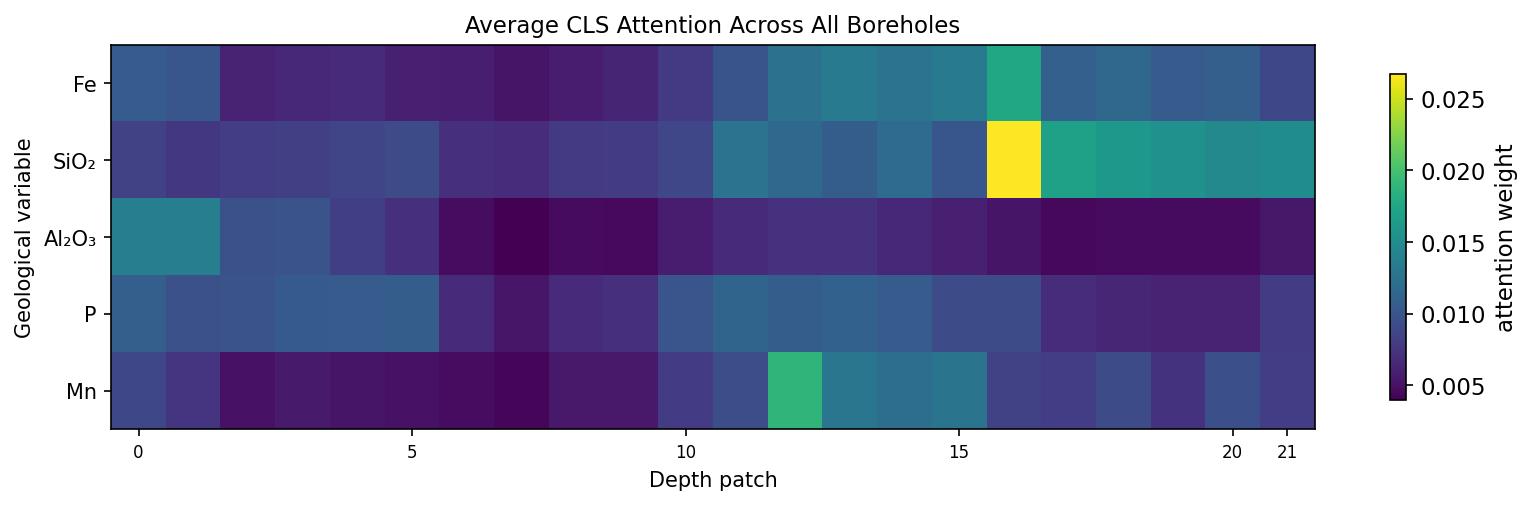


📊 Global attention heatmap:
  Most attended variable    : SiO₂ (index 1)
  Most attended depth patch : 16  (~320–340 m)
  Attention range           : [0.00395, 0.02674]
  Bright cells indicate depth–variable combinations the CLS token
  consistently queries across all boreholes.


In [11]:
# ── A) Mean attention heatmap ──────────────────────────────────────────────
global_mean = attn_mean_per_sample.mean(axis=0)  # (V, P)

fig, ax = plt.subplots(figsize=(11, 3.5))
im = make_heatmap(ax, global_mean, "Average CLS Attention Across All Boreholes", VAR_NAMES)
plt.colorbar(im, ax=ax, label="attention weight", shrink=0.85)
plt.tight_layout()
fig.savefig(PLOT_DIR / "global_attention_heatmap.png", bbox_inches="tight")
plt.show()

top_var_idx   = global_mean.sum(axis=1).argmax()
top_patch_idx = global_mean.sum(axis=0).argmax()
print("\n📊 Global attention heatmap:")
print(f"  Most attended variable    : {VAR_NAMES[top_var_idx]} (index {top_var_idx})")
print(f"  Most attended depth patch : {top_patch_idx}  (~{top_patch_idx*20}–{top_patch_idx*20+20} m)")
print(f"  Attention range           : [{global_mean.min():.5f}, {global_mean.max():.5f}]")
print("  Bright cells indicate depth–variable combinations the CLS token")
print("  consistently queries across all boreholes.")

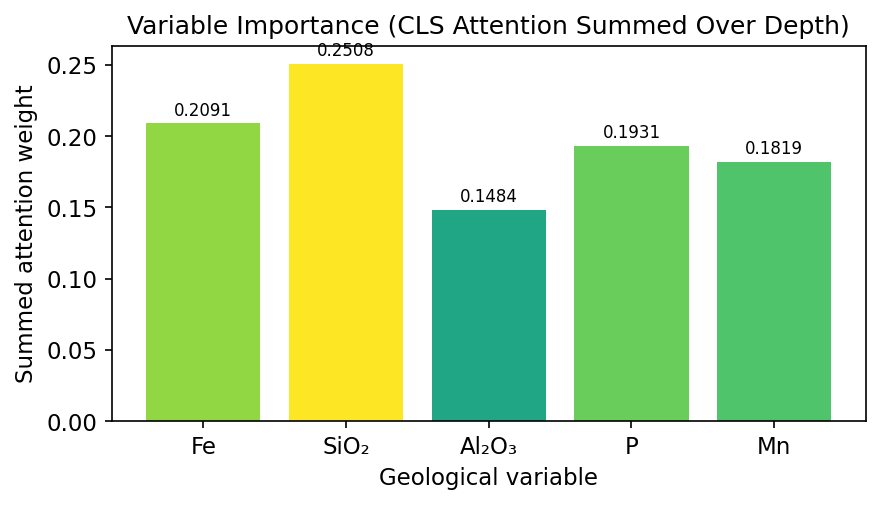


📊 Variable importance (ranked):
  1. SiO₂     0.25077
  2. Fe       0.20907
  3. P        0.19308
  4. Mn       0.18194
  5. Al₂O₃    0.14842
  Variables with high summed attention are consistently queried
  by the CLS token regardless of depth patch.


In [12]:
# ── B) Variable importance ─────────────────────────────────────────────────
var_imp = variable_importance(global_mean)  # (V,)

fig, ax = plt.subplots(figsize=(6, 3.5))
colors = plt.cm.viridis(var_imp / var_imp.max())
bars = ax.bar(VAR_NAMES, var_imp, color=colors)
ax.set_xlabel("Geological variable")
ax.set_ylabel("Summed attention weight")
ax.set_title("Variable Importance (CLS Attention Summed Over Depth)")
ax.bar_label(bars, fmt="%.4f", padding=2, fontsize=8)
plt.tight_layout()
fig.savefig(PLOT_DIR / "variable_importance.png", bbox_inches="tight")
plt.show()

ranked = sorted(zip(var_imp.tolist(), VAR_NAMES), reverse=True)
print("\n📊 Variable importance (ranked):")
for rank, (w, name) in enumerate(ranked, 1):
    print(f"  {rank}. {name:<8} {w:.5f}")
print("  Variables with high summed attention are consistently queried")
print("  by the CLS token regardless of depth patch.")

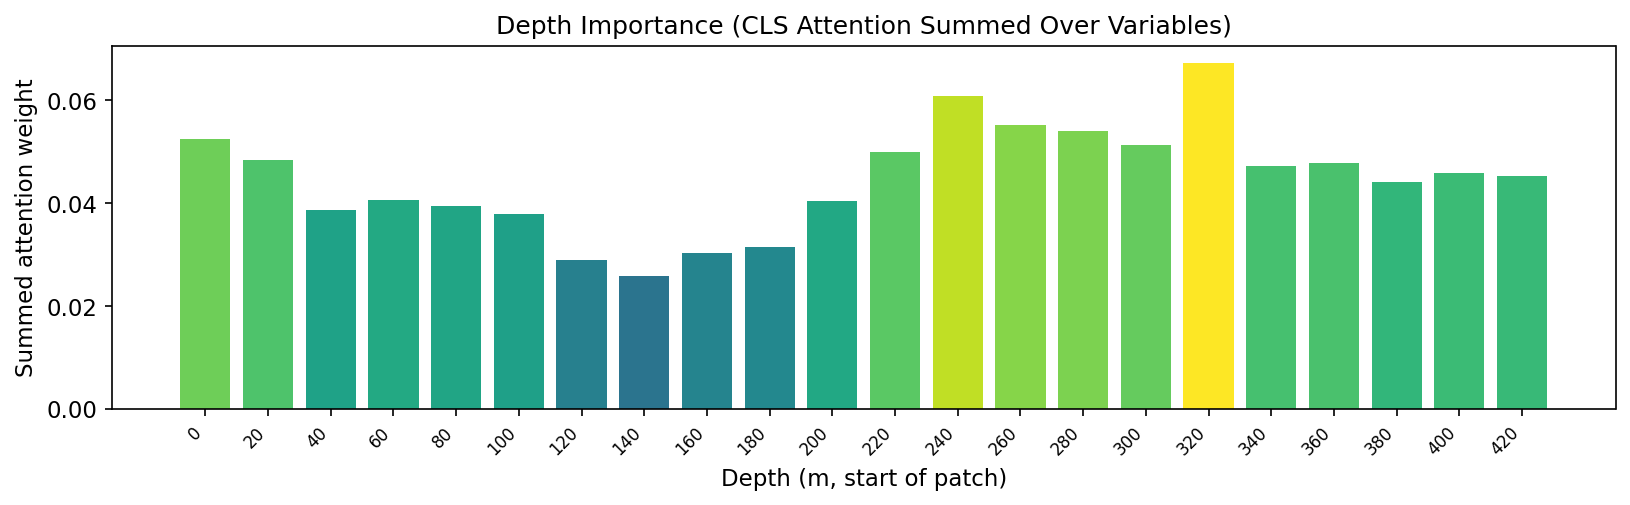


📊 Depth importance:
  Top 3 patches: patch 16 (~320 m), patch 12 (~240 m), patch 13 (~260 m)
  Peaks indicate depth intervals where geological variables carry
  the most information for the CLS borehole embedding.


In [13]:
# ── C) Depth importance ────────────────────────────────────────────────────
depth_imp = depth_importance(global_mean)  # (P,)
depth_labels = [str(i * 20) for i in range(N_PATCHES)]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(range(N_PATCHES), depth_imp, color=plt.cm.viridis(depth_imp / depth_imp.max()))
ax.set_xticks(range(N_PATCHES))
ax.set_xticklabels(depth_labels, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Depth (m, start of patch)")
ax.set_ylabel("Summed attention weight")
ax.set_title("Depth Importance (CLS Attention Summed Over Variables)")
plt.tight_layout()
fig.savefig(PLOT_DIR / "depth_importance.png", bbox_inches="tight")
plt.show()

top3 = np.argsort(depth_imp)[::-1][:3]
print("\n📊 Depth importance:")
print("  Top 3 patches: " + ", ".join(f"patch {p} (~{p*20} m)" for p in top3))
print("  Peaks indicate depth intervals where geological variables carry")
print("  the most information for the CLS borehole embedding.")

## 5 · Ore vs No-Ore Analysis

C:\Users\denni\AppData\Local\Temp\ipykernel_15836\3302945310.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


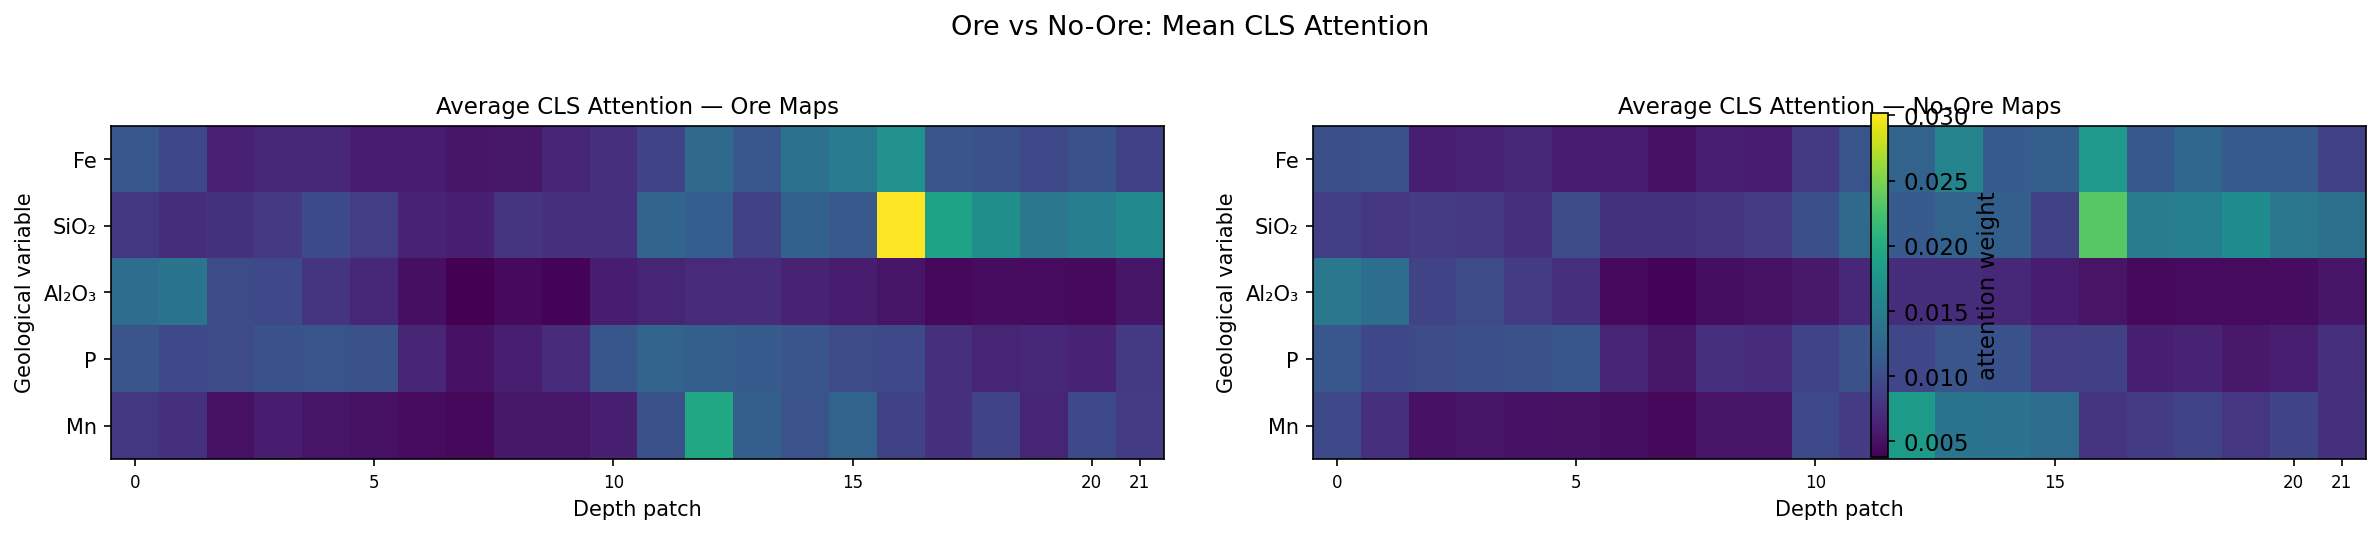


📊 Ore vs No-Ore mean attention (shared scale):
  Ore    range : [0.00383, 0.03018]
  No-Ore range : [0.00408, 0.02330]
  A shared color scale makes patterns directly comparable.


In [14]:
ore_mean    = attn_mean_per_sample[ore_mask].mean(axis=0)     # (V, P)
no_ore_mean = attn_mean_per_sample[no_ore_mask].mean(axis=0)  # (V, P)
diff        = ore_mean - no_ore_mean                           # (V, P)

shared_vmin = min(ore_mean.min(), no_ore_mean.min())
shared_vmax = max(ore_mean.max(), no_ore_mean.max())

# ── Ore & No-Ore side-by-side ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 3.5))
im1 = make_heatmap(axes[0], ore_mean,    "Average CLS Attention — Ore Maps",    VAR_NAMES,
                   vmin=shared_vmin, vmax=shared_vmax)
im2 = make_heatmap(axes[1], no_ore_mean, "Average CLS Attention — No-Ore Maps", VAR_NAMES,
                   vmin=shared_vmin, vmax=shared_vmax)
fig.colorbar(im2, ax=axes, label="attention weight", shrink=0.85, pad=0.02)
plt.suptitle("Ore vs No-Ore: Mean CLS Attention", fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(PLOT_DIR / "ore_heatmap.png",    bbox_inches="tight")
fig.savefig(PLOT_DIR / "no_ore_heatmap.png", bbox_inches="tight")
plt.show()

print("\n📊 Ore vs No-Ore mean attention (shared scale):")
print(f"  Ore    range : [{ore_mean.min():.5f}, {ore_mean.max():.5f}]")
print(f"  No-Ore range : [{no_ore_mean.min():.5f}, {no_ore_mean.max():.5f}]")
print("  A shared color scale makes patterns directly comparable.")

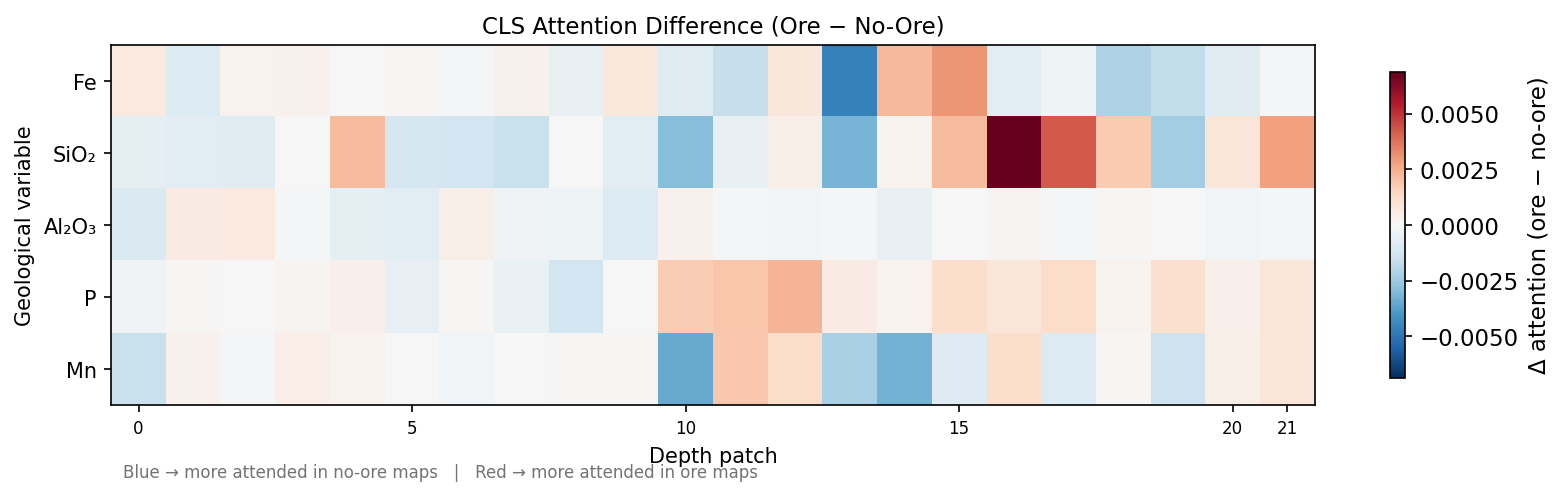


📊 Attention difference (Ore − No-Ore):
  Largest ore-specific    : SiO₂, patch 16  (Δ = +0.00688)
  Largest no-ore-specific : Fe, patch 13  (Δ = -0.00464)
  Max absolute difference : 0.00688
  Red cells mark (variable, depth) pairs the encoder preferentially
  attends to when ore is present; blue cells the reverse.
  Differences may reflect distributional shifts in the geology, not
  causal features — treat as hypothesis-generating, not conclusive.


In [15]:
# ── Difference heatmap ─────────────────────────────────────────────────────
abs_max  = float(np.abs(diff).max())
norm_div = TwoSlopeNorm(vmin=-abs_max, vcenter=0.0, vmax=abs_max)

fig, ax = plt.subplots(figsize=(11, 3.5))
im = make_heatmap(ax, diff,
                  "CLS Attention Difference (Ore − No-Ore)",
                  VAR_NAMES, cmap="RdBu_r", norm=norm_div)
plt.colorbar(im, ax=ax, label="Δ attention (ore − no-ore)", shrink=0.85)
ax.text(0.01, -0.20,
        "Blue → more attended in no-ore maps   |   Red → more attended in ore maps",
        transform=ax.transAxes, fontsize=8, color="0.45")
plt.tight_layout()
fig.savefig(PLOT_DIR / "difference_heatmap.png", bbox_inches="tight")
plt.show()

top_ore_cell   = np.unravel_index(diff.argmax(), diff.shape)
top_noore_cell = np.unravel_index(diff.argmin(), diff.shape)

print("\n📊 Attention difference (Ore − No-Ore):")
print(f"  Largest ore-specific    : {VAR_NAMES[top_ore_cell[0]]}, patch {top_ore_cell[1]}  (Δ = +{diff[top_ore_cell]:.5f})")
print(f"  Largest no-ore-specific : {VAR_NAMES[top_noore_cell[0]]}, patch {top_noore_cell[1]}  (Δ = {diff[top_noore_cell]:.5f})")
print(f"  Max absolute difference : {abs_max:.5f}")
print("  Red cells mark (variable, depth) pairs the encoder preferentially")
print("  attends to when ore is present; blue cells the reverse.")
print("  Differences may reflect distributional shifts in the geology, not")
print("  causal features — treat as hypothesis-generating, not conclusive.")

## 6 · Most Attended Regions

Top 10 most frequently argmax-attended (variable, patch) combinations:

Variable  Patch Depth (m)  Frequency Fraction
    SiO₂     16   320–340         14    14.0%
    SiO₂     18   360–380          9     9.0%
    SiO₂     19   380–400          8     8.0%
      Fe     16   320–340          8     8.0%
    SiO₂     17   340–360          5     5.0%
    SiO₂     20   400–420          4     4.0%
      Mn     12   240–260          4     4.0%
    SiO₂     21   420–440          4     4.0%
      Fe     15   300–320          3     3.0%
      Fe     13   260–280          3     3.0%


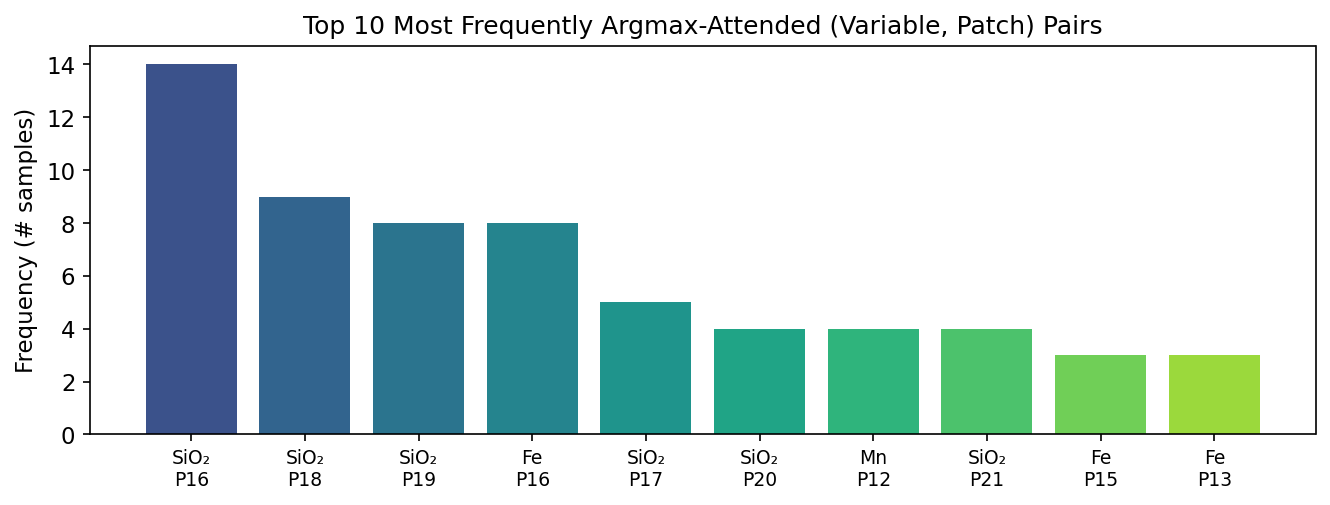


📊 Interpretation:
  Concentrated top-10 → encoder reads a near-fixed position across boreholes.
  Flat / many unique pairs → encoder adapts its focus per borehole.


In [16]:
# Argmax (variable, patch) per sample
flat_idx     = attn_mean_per_sample.reshape(n_samples, -1).argmax(axis=1)  # (N,)
argmax_var   = flat_idx // N_PATCHES
argmax_patch = flat_idx  % N_PATCHES

counts = Counter(zip(argmax_var.tolist(), argmax_patch.tolist()))
top10  = counts.most_common(10)

top10_df = pd.DataFrame([
    {"Variable": VAR_NAMES[v],
     "Patch":    p,
     "Depth (m)": f"{p*20}–{p*20+20}",
     "Frequency": f,
     "Fraction":  f"{f/n_samples:.1%}"}
    for (v, p), f in top10
])

print("Top 10 most frequently argmax-attended (variable, patch) combinations:\n")
print(top10_df.to_string(index=False))

labels_top = [f"{VAR_NAMES[v]}\nP{p}" for (v, p), _ in top10]
freqs_top  = [f for _, f in top10]

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(range(len(top10)), freqs_top,
       color=plt.cm.viridis(np.linspace(0.25, 0.85, len(top10))))
ax.set_xticks(range(len(top10)))
ax.set_xticklabels(labels_top, fontsize=9)
ax.set_ylabel("Frequency (# samples)")
ax.set_title("Top 10 Most Frequently Argmax-Attended (Variable, Patch) Pairs")
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("  Concentrated top-10 → encoder reads a near-fixed position across boreholes.")
print("  Flat / many unique pairs → encoder adapts its focus per borehole.")

## 7 · Attention Variability

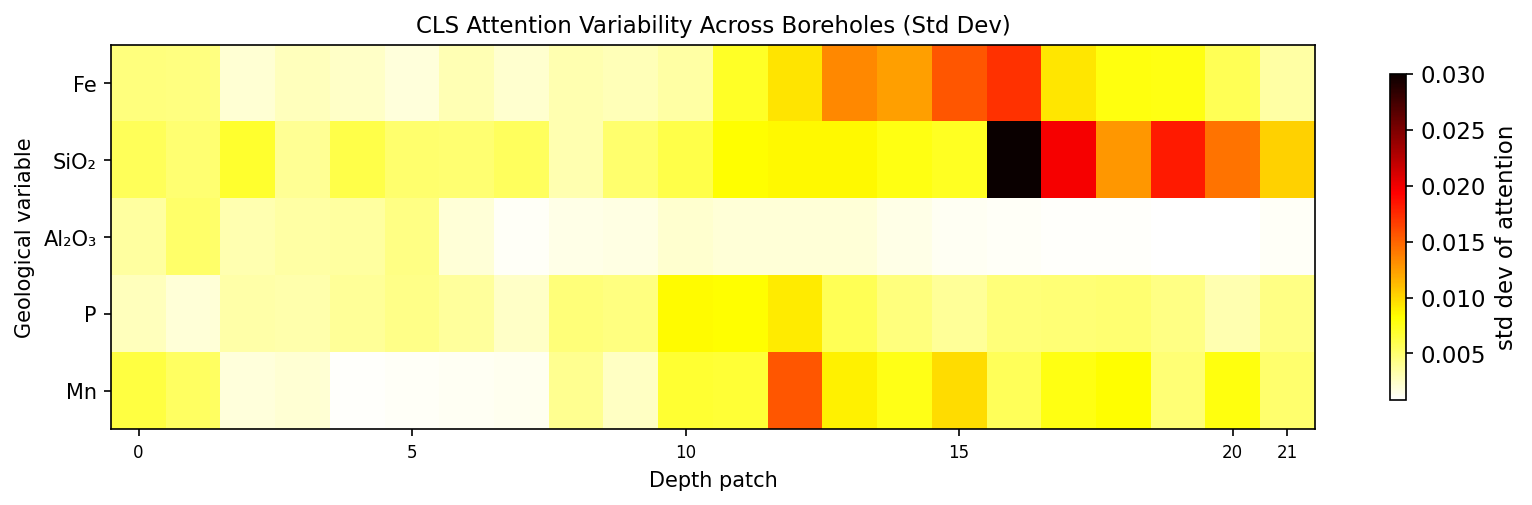


📊 Attention variability:
  Highest-variability cell : SiO₂, patch 16  (σ = 0.03002)
  Lowest-variability  cell : Al₂O₃, patch 19   (σ = 0.00081)
  Mean std across all cells: 0.00560
  High-variability cells are sample-specific; low-variability cells are
  attended (or not) regardless of geology.
  High variability combined with a large ore/no-ore difference in the same
  region is the strongest signal that the encoder uses it discriminatively.


In [17]:
attn_std = attn_mean_per_sample.std(axis=0)  # (V, P)

fig, ax = plt.subplots(figsize=(11, 3.5))
im = make_heatmap(ax, attn_std,
                  "CLS Attention Variability Across Boreholes (Std Dev)",
                  VAR_NAMES, cmap="hot_r")
plt.colorbar(im, ax=ax, label="std dev of attention", shrink=0.85)
plt.tight_layout()
fig.savefig(PLOT_DIR / "variability_heatmap.png", bbox_inches="tight")
plt.show()

high_var_cell = np.unravel_index(attn_std.argmax(), attn_std.shape)
low_var_cell  = np.unravel_index(attn_std.argmin(), attn_std.shape)

print("\n📊 Attention variability:")
print(f"  Highest-variability cell : {VAR_NAMES[high_var_cell[0]]}, patch {high_var_cell[1]}  (σ = {attn_std[high_var_cell]:.5f})")
print(f"  Lowest-variability  cell : {VAR_NAMES[low_var_cell[0]]}, patch {low_var_cell[1]}   (σ = {attn_std[low_var_cell]:.5f})")
print(f"  Mean std across all cells: {attn_std.mean():.5f}")
print("  High-variability cells are sample-specific; low-variability cells are")
print("  attended (or not) regardless of geology.")
print("  High variability combined with a large ore/no-ore difference in the same")
print("  region is the strongest signal that the encoder uses it discriminatively.")

## 8 · Combined Thesis Figure

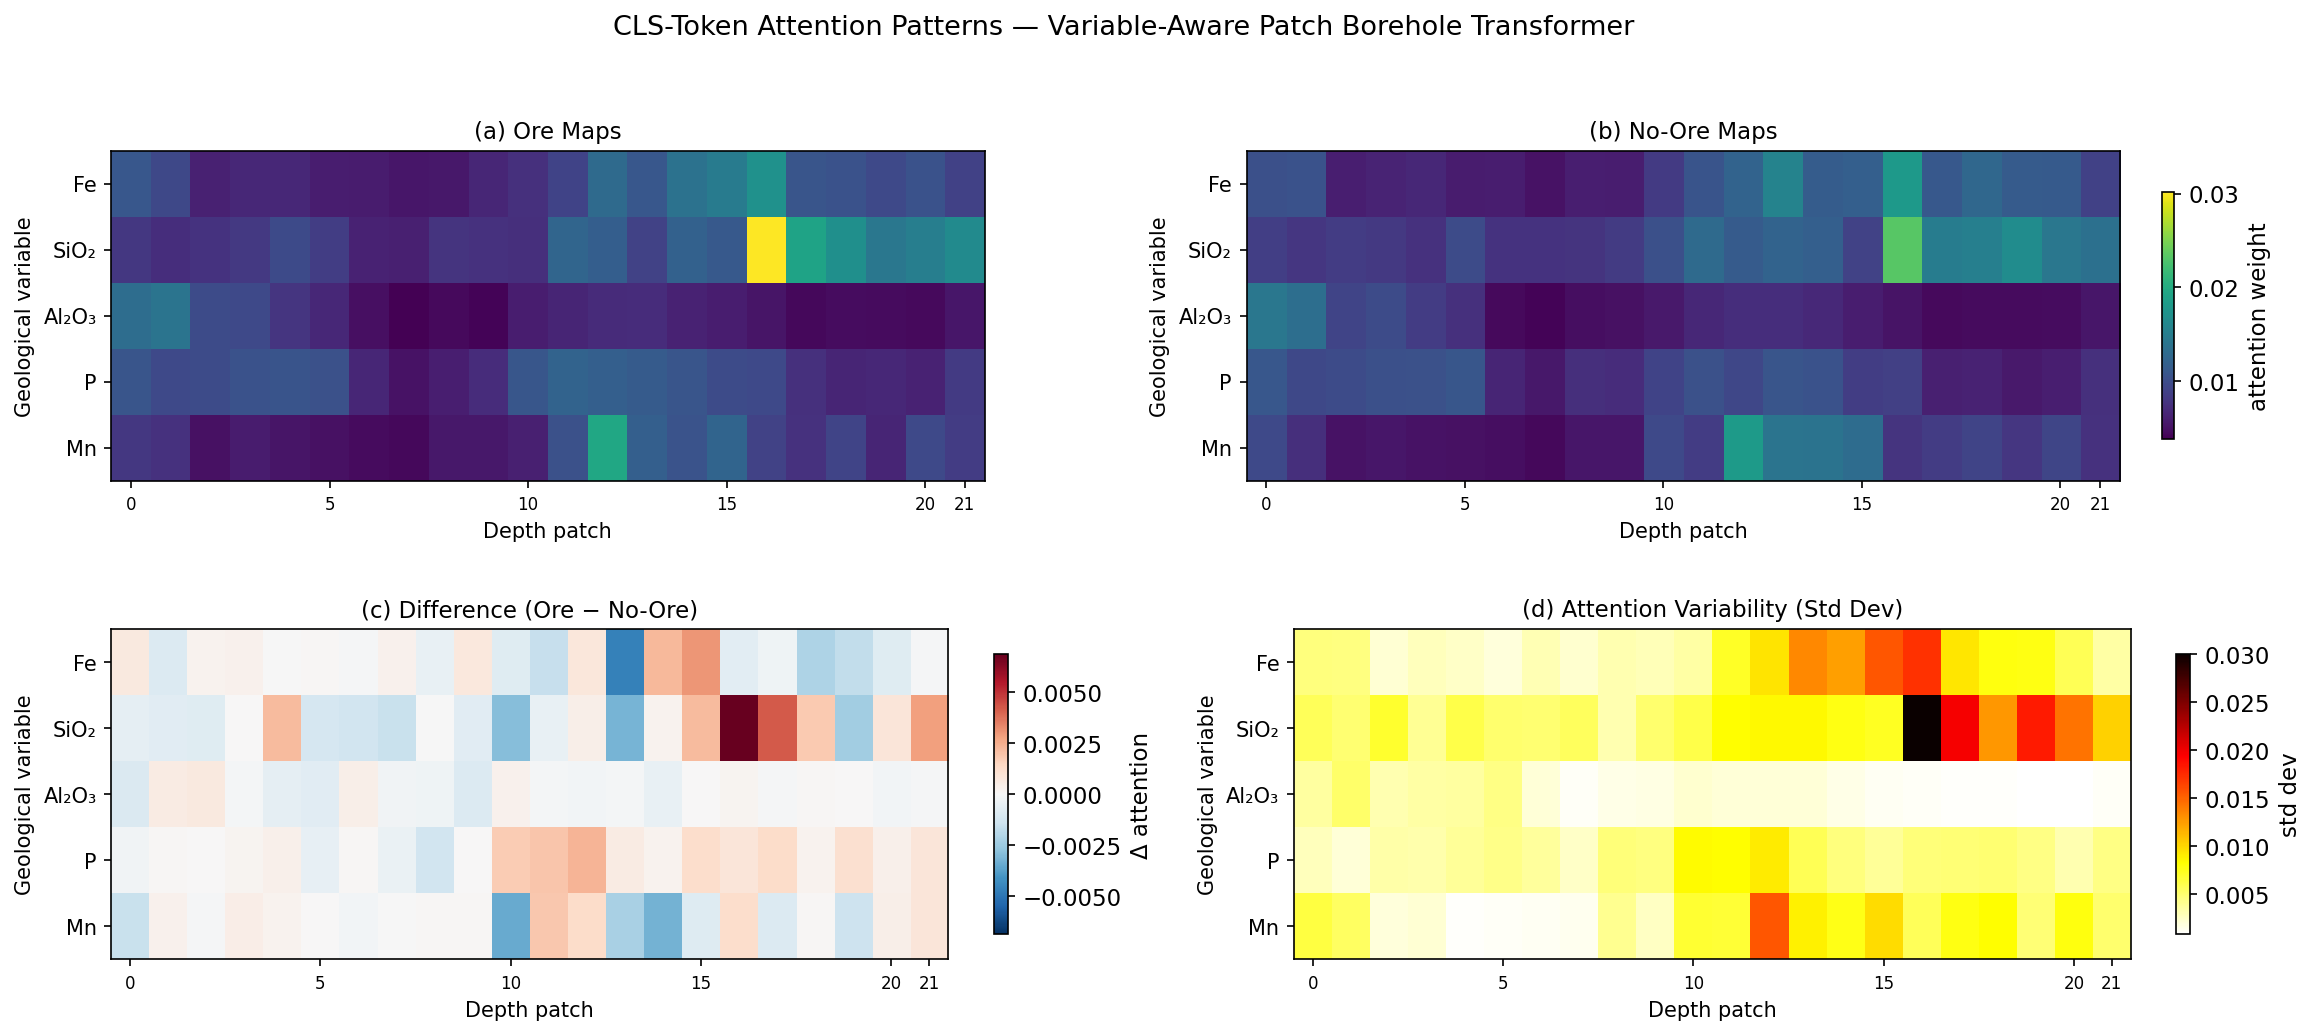

Combined figure saved → 'attention_analysis\combined_attention_analysis.png'


In [18]:
fig = plt.figure(figsize=(18, 7))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.3)

ax_ore   = fig.add_subplot(gs[0, 0])
ax_noore = fig.add_subplot(gs[0, 1])
ax_diff  = fig.add_subplot(gs[1, 0])
ax_var   = fig.add_subplot(gs[1, 1])

shared_vmin = min(ore_mean.min(), no_ore_mean.min())
shared_vmax = max(ore_mean.max(), no_ore_mean.max())

im_ore   = make_heatmap(ax_ore,   ore_mean,    "(a) Ore Maps",    VAR_NAMES,
                         vmin=shared_vmin, vmax=shared_vmax)
im_noore = make_heatmap(ax_noore, no_ore_mean, "(b) No-Ore Maps", VAR_NAMES,
                         vmin=shared_vmin, vmax=shared_vmax)
fig.colorbar(im_noore, ax=[ax_ore, ax_noore],
             label="attention weight", shrink=0.75, pad=0.02, fraction=0.02)

abs_max  = float(np.abs(diff).max())
norm_div = TwoSlopeNorm(vmin=-abs_max, vcenter=0.0, vmax=abs_max)
im_diff  = make_heatmap(ax_diff, diff, "(c) Difference (Ore − No-Ore)",
                         VAR_NAMES, cmap="RdBu_r", norm=norm_div)
fig.colorbar(im_diff, ax=ax_diff, label="Δ attention", shrink=0.85, fraction=0.03)

im_var = make_heatmap(ax_var, attn_std, "(d) Attention Variability (Std Dev)",
                       VAR_NAMES, cmap="hot_r")
fig.colorbar(im_var, ax=ax_var, label="std dev", shrink=0.85, fraction=0.03)

fig.suptitle(
    "CLS-Token Attention Patterns — Variable-Aware Patch Borehole Transformer",
    fontsize=13, y=1.01,
)

combined_path = PLOT_DIR / "combined_attention_analysis.png"
fig.savefig(combined_path, bbox_inches="tight", dpi=200)
plt.show()
print(f"Combined figure saved → '{combined_path}'")

## 9 · Saved Files Summary

In [19]:
expected = [
    "global_attention_heatmap.png",
    "variable_importance.png",
    "depth_importance.png",
    "ore_heatmap.png",
    "no_ore_heatmap.png",
    "difference_heatmap.png",
    "variability_heatmap.png",
    "combined_attention_analysis.png",
]

print(f"Output directory : {PLOT_DIR.resolve()}\n")
for fname in expected:
    ok = (PLOT_DIR / fname).exists()
    print(f"  {'✓' if ok else '✗ MISSING'}  {fname}")

print(f"\n{'='*50}")
print("Analysis complete.")
print(f"  {n_samples} boreholes analysed")
print(f"  {no_ore_mask.sum()} no-ore  /  {ore_mask.sum()} ore")
print(f"  Attention : (n_layers={n_layers}, n_heads={n_heads}, V={V}, P={P})")
print(f"  Latent dim: {latent_dim}")
print('='*50)

Output directory : C:\Users\denni\OneDrive\Documenten\ADS\Thesis\RL-Boreholes\attention_analysis

  ✓  global_attention_heatmap.png
  ✓  variable_importance.png
  ✓  depth_importance.png
  ✓  ore_heatmap.png
  ✓  no_ore_heatmap.png
  ✓  difference_heatmap.png
  ✓  variability_heatmap.png
  ✓  combined_attention_analysis.png

Analysis complete.
  100 boreholes analysed
  50 no-ore  /  50 ore
  Attention : (n_layers=2, n_heads=4, V=5, P=22)
  Latent dim: 128
